1) Imports

In [94]:
import os
import re
import pandas as pd
import numpy as np

2) Define the data path

In [95]:
data_path = "../data/raw"

3) List all excel files 

In [96]:
files = os.listdir(data_path)

excel_files = [f for f in files if f.endswith(".xlsx")]
excel_files


['avis_33_traduit.xlsx',
 'avis_34_traduit.xlsx',
 'avis_21_traduit.xlsx',
 'avis_26_traduit.xlsx',
 'avis_10_traduit.xlsx',
 'avis_17_traduit.xlsx',
 'avis_27_traduit.xlsx',
 'avis_20_traduit.xlsx',
 'avis_35_traduit.xlsx',
 'avis_32_traduit.xlsx',
 'avis_16_traduit.xlsx',
 'avis_11_traduit.xlsx',
 'avis_7_traduit.xlsx',
 'avis_1_traduit.xlsx',
 'avis_6_traduit.xlsx',
 'avis_18_traduit.xlsx',
 'avis_4_traduit.xlsx',
 'avis_3_traduit.xlsx',
 'avis_29_traduit.xlsx',
 'avis_19_traduit.xlsx',
 'avis_2_traduit.xlsx',
 'avis_5_traduit.xlsx',
 'avis_28_traduit.xlsx',
 'avis_22_traduit.xlsx',
 'avis_25_traduit.xlsx',
 'avis_30_traduit.xlsx',
 'avis_13_traduit.xlsx',
 'avis_14_traduit.xlsx',
 'avis_8_traduit.xlsx',
 'avis_31_traduit.xlsx',
 'avis_24_traduit.xlsx',
 'avis_23_traduit.xlsx',
 'avis_15_traduit.xlsx',
 'avis_12_traduit.xlsx',
 'avis_9_traduit.xlsx']

4) Number of files found

In [97]:
len(excel_files)

35

5) Load and merge all excel files

In [98]:
dfs = []

for file in excel_files:
    path = os.path.join(data_path, file) 
    df_temp = pd.read_excel(path) 
    df_temp["source_file"] = file # we add a new column with the file name
    dfs.append(df_temp) 

df = pd.concat(dfs, ignore_index=True) 

6) Preview the dataset

In [99]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file
0,NaN,estelle-51227,j'ai quitté mon ancien contrat d'assurance che...,Néoliane Santé,sante,test,12/01/2017,01/01/2017,I left my former insurance contract at General...,NaN,NaN,avis_33_traduit.xlsx
1,NaN,leadum-51107,j'ai souscrit à cette mutuelle l'année dernier...,Néoliane Santé,sante,test,09/01/2017,01/01/2017,I subscribed to this mutual a year last year a...,NaN,NaN,avis_33_traduit.xlsx
2,NaN,enora-49520,"Impossible d'avoir le bon service , ils raccro...",Néoliane Santé,sante,test,24/11/2016,01/11/2016,"Impossible to have the right service, they han...",NaN,NaN,avis_33_traduit.xlsx
3,NaN,bea-139295,Génération est une mutuelle très chère pour un...,Génération,sante,test,09/11/2021,01/11/2021,Generation is a very expensive mutual for a re...,NaN,NaN,avis_33_traduit.xlsx
4,NaN,anna-139192,je viens d apprendre que je suis radié... j ap...,Génération,sante,test,08/11/2021,01/11/2021,I just learned that I am struck off ... I call...,NaN,NaN,avis_33_traduit.xlsx


7) We check the dataset size to see if it was concatenate correctly 

In [100]:
df.shape

(34435, 12)

8) Display the columns names

In [101]:
df.columns.tolist()

['note',
 'auteur',
 'avis',
 'assureur',
 'produit',
 'type',
 'date_publication',
 'date_exp',
 'avis_en',
 'avis_cor',
 'avis_cor_en',
 'source_file']

9) Dataframe info

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  object 
 2   avis              34435 non-null  object 
 3   assureur          34435 non-null  object 
 4   produit           34435 non-null  object 
 5   type              34435 non-null  object 
 6   date_publication  34435 non-null  object 
 7   date_exp          34435 non-null  object 
 8   avis_en           34433 non-null  object 
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
 11  source_file       34435 non-null  object 
dtypes: float64(1), object(11)
memory usage: 3.2+ MB


10) Missing values

In [103]:
df.isna().sum().sort_values(ascending=False)

avis_cor_en         34004
avis_cor            34000
note                10331
avis_en                 2
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
source_file             0
dtype: int64

We have zero missing values in the "avis" columns but there is a lot a missing values in "avis_corr_en" and "avis_corr" (more than 98%). We should drop those columns. 

10.1) Drop useless columns

In [104]:
df = df.drop(columns=["avis_cor", "avis_cor_en"])

11) Remove exact duplicates

In [105]:
df = df.drop_duplicates().copy()
df.shape

(34434, 10)

12) We define a basic text cleaning fucntion

In [106]:
def clean_text(text):
    text = str(text).lower() # we convert to string and lowercase
    text = re.sub(r"http\S+|www\S+", " ", text) # we remove all the URLs
    text = re.sub(r"\n|\r|\t", " ", text) 
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s]", " ", text) # we remove all the special characters except for letters, numbers and spaces
    text = re.sub(r"\s+", " ", text).strip() # we remove extra spaces
    return text

13) We create a cleaned review colum

In [107]:
df["avis_clean"] = df["avis"].apply(clean_text)

14) We compare original vs cleaned text

In [108]:
df[["avis", "avis_clean"]].head(10)

,avis,avis_clean
0,j'ai quitté mon ancien contrat d'assurance che...,j ai quitté mon ancien contrat d assurance che...
1,j'ai souscrit à cette mutuelle l'année dernier...,j ai souscrit à cette mutuelle l année dernier...
2,"Impossible d'avoir le bon service , ils raccro...",impossible d avoir le bon service ils raccroch...
3,Génération est une mutuelle très chère pour un...,génération est une mutuelle très chère pour un...
4,je viens d apprendre que je suis radié... j ap...,je viens d apprendre que je suis radié j appel...
5,"Service client très accessible, temps d’attent...",service client très accessible temps d attente...
6,Réactivité des professionnels à l écoute \nJe ...,réactivité des professionnels à l écoute je tr...
7,Catastrophique en relation client. Depuis des ...,catastrophique en relation client depuis des m...
8,jai pris contacte avec vos service se jour pou...,jai pris contacte avec vos service se jour pou...
9,Je suis toujours dans l'attente du rembourseme...,je suis toujours dans l attente du rembourseme...


15) We remove empty cleaned reviews

In [109]:
df = df[df["avis_clean"].str.len() > 0].copy() 
df.shape

(34433, 11)

16) We check the distribution of ratings 

In [110]:
df["note"].value_counts().sort_index()

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64

We can add a visualization

/var/folders/h5/fthz7w1d6l1_w09sqsgml2vm0000gn/T/ipykernel_1076/940500055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="note", data=df_supervised, palette="viridis")


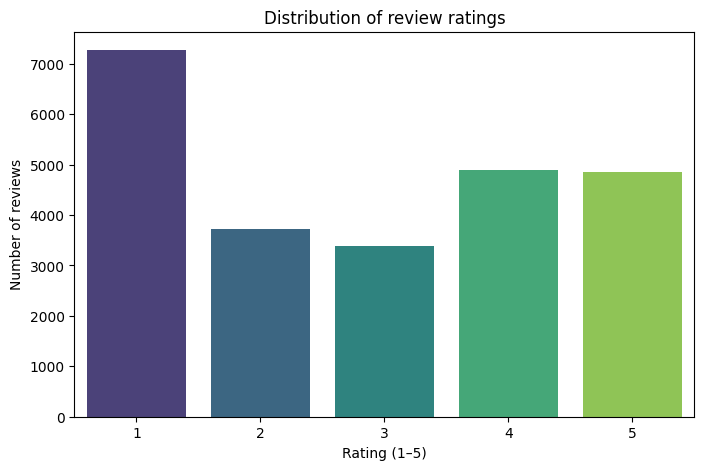

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x="note", data=df_supervised, palette="viridis")

plt.title("Distribution of review ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Number of reviews")

plt.show()

17) We convert the date columns in datetime

In [112]:
for col in ["date_publication", "date_exp"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

df[["date_publication", "date_exp"]].head()

,date_publication,date_exp
0,2017-01-12,2017-01-01
1,2017-01-09,2017-01-01
2,2016-11-24,2016-11-01
3,2021-11-09,2021-11-01
4,2021-11-08,2021-11-01


18) Labeled subset for supervised learning

We previously saw that note has many missing values so we wil create a labeled subset for supervised learning with only the rows containing a non null value

In [113]:
df_supervised = df.dropna(subset=["note"]).copy() 
df_supervised["note"] = df_supervised["note"].astype(int) 

df_supervised.shape

(24104, 11)

We check the rating distribution

18) We save the cleaned dataset

In [114]:
df.to_csv("../data/processed/reviews_clean.csv", index=False)
df_supervised.to_csv("../data/processed/reviews_supervised.csv", index=False)

Final check

In [115]:
print("Full cleaned dataset shape:", df.shape)
print("Supervised dataset shape:", df_supervised.shape)

Full cleaned dataset shape: (34433, 11)
Supervised dataset shape: (24104, 11)
